
 >>> Processing Noise Level: Sigma = 15 <<<
Loading training data from folders for Sigma=15...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:28<00:00,  1.10it/s]



--- Result (Sigma=15) ---
Original Noisy PSNR: 28.12 dB
Denoised PSNR:       32.1698 dB
Denoised SSIM:       0.6644
Saved: svr_bsd68_result_sigma15.png

 >>> Processing Noise Level: Sigma = 25 <<<
Loading training data from folders for Sigma=25...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:36<00:00,  1.17s/it]



--- Result (Sigma=25) ---
Original Noisy PSNR: 23.71 dB
Denoised PSNR:       30.6382 dB
Denoised SSIM:       0.6020
Saved: svr_bsd68_result_sigma25.png

 >>> Processing Noise Level: Sigma = 50 <<<
Loading training data from folders for Sigma=50...
Training SVR (Samples: 10000)...
Training Done.


Inference: 100%|██████████| 31/31 [00:40<00:00,  1.32s/it]



--- Result (Sigma=50) ---
Original Noisy PSNR: 17.82 dB
Denoised PSNR:       28.2767 dB
Denoised SSIM:       0.5073
Saved: svr_bsd68_result_sigma50.png

########################################
Final Summary
########################################
Sigma      Noisy PSNR      Denoised PSNR   SSIM      
15         28.12 dB         32.17 dB         0.6644
25         23.71 dB         30.64 dB         0.6020
50         17.82 dB         28.28 dB         0.5073


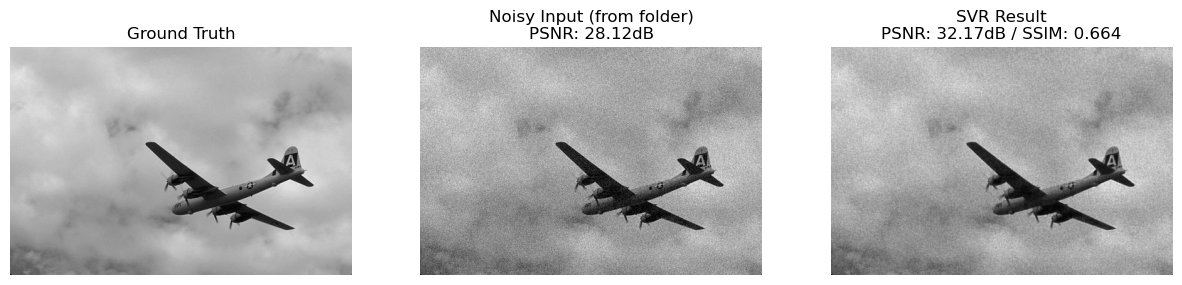

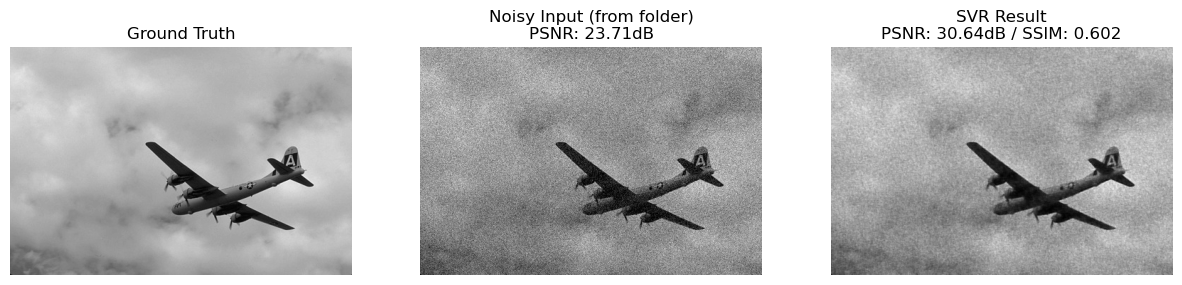

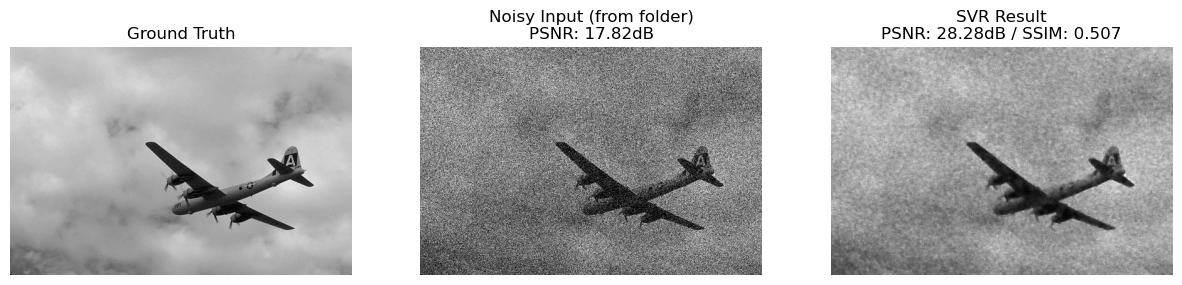

In [6]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.util import view_as_windows
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from tqdm import tqdm

# ============================
# Configuration
# ============================
# Path to the root of BSD68 dataset containing 'original', 'noisy15', etc.
BSD68_ROOT = "data/BSD68" 

# Sigmas to train and test
SIGMA_LIST = [15, 25, 50]

# SVR Parameters
PATCH_SIZE = 7
NUM_TRAIN_PATCHES = 10000 

# ============================
# Helper Functions
# ============================
def get_image_paths(root_dir, subfolder):
    """
    Get sorted list of image paths from a subfolder.
    Sorting ensures 'test001.png' in noisy matches 'test001.png' in original.
    """
    full_path = os.path.join(root_dir, subfolder)
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Folder not found: {full_path}")
    
    # Grab png or jpg files
    files = sorted([
        f for f in os.listdir(full_path) 
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])
    
    return [os.path.join(full_path, f) for f in files]

def load_training_data_from_folders(root_dir, sigma, num_patches=5000, patch_size=7):
    """
    Load pairs from 'original' and 'noisy{sigma}' folders directly.
    """
    print(f"Loading training data from folders for Sigma={sigma}...")
    
    # 1. Get Clean and Noisy paths
    clean_folder = "original_png" if os.path.exists(os.path.join(root_dir, "original_png")) else "original"
    noisy_folder = f"noisy{sigma}"
    
    clean_paths = get_image_paths(root_dir, clean_folder)
    noisy_paths = get_image_paths(root_dir, noisy_folder)
    
    if len(clean_paths) != len(noisy_paths):
        raise ValueError(f"Mismatch! Clean images: {len(clean_paths)}, Noisy images: {len(noisy_paths)}")
        
    X_train = []
    y_train = []
    
    # 2. Randomly sample patches
    patches_collected = 0
    max_attempts = num_patches * 5
    attempts = 0
    
    while patches_collected < num_patches and attempts < max_attempts:
        attempts += 1
        
        # Pick a random image index
        idx = np.random.randint(0, len(clean_paths))
        
        # Load the pair
        img_clean = cv2.imread(clean_paths[idx], cv2.IMREAD_GRAYSCALE)
        img_noisy = cv2.imread(noisy_paths[idx], cv2.IMREAD_GRAYSCALE)
        
        if img_clean is None or img_noisy is None: continue
        
        # Normalize
        img_clean = img_clean.astype(np.float32) / 255.0
        img_noisy = img_noisy.astype(np.float32) / 255.0
        
        # Extract random patch
        h, w = img_clean.shape
        if h <= patch_size or w <= patch_size: continue
        
        r = np.random.randint(0, h - patch_size)
        c = np.random.randint(0, w - patch_size)
        
        # Input: Noisy Patch
        patch_noisy = img_noisy[r:r+patch_size, c:c+patch_size]
        # Target: Clean Center Pixel
        pixel_clean = img_clean[r+patch_size//2, c+patch_size//2]
        
        X_train.append(patch_noisy.flatten())
        y_train.append(pixel_clean)
        patches_collected += 1
        
    return np.array(X_train), np.array(y_train)

class SVRDenoiser:
    def __init__(self, C=10, epsilon=0.02, gamma=0.05):
        self.model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
        self.patch_size = 7
        
    def train(self, X, y):
        print(f"Training SVR (Samples: {len(X)})...")
        self.model.fit(X, y)
        print("Training Done.")
        
    def predict(self, noisy_img):
        h, w = noisy_img.shape
        pad = self.patch_size // 2
        img_padded = np.pad(noisy_img, ((pad, pad), (pad, pad)), mode='symmetric')
        windows = view_as_windows(img_padded, (self.patch_size, self.patch_size))
        X_test = windows.reshape(h * w, -1)
        
        # Batch prediction
        batch_size = 5000
        preds = []
        for i in tqdm(range(0, len(X_test), batch_size), desc="Inference"):
            preds.append(self.model.predict(X_test[i:i+batch_size]))
            
        return np.concatenate(preds).reshape(h, w)

# ============================
# Main Logic
# ============================
if __name__ == "__main__":

    # Check BSD68 structure first
    if not os.path.exists(BSD68_ROOT):
        print(f"Error: {BSD68_ROOT} not found.")
        exit()

    summary = {}

    for sigma in SIGMA_LIST:
        print(f"\n{'='*60}")
        print(f" >>> Processing Noise Level: Sigma = {sigma} <<<")
        print(f"{'='*60}")
        
        # --- 1. Prepare Training Data ---
        # Instead of adding noise manually, we load the pre-existing noisy files
        try:
            X_train, y_train = load_training_data_from_folders(
                BSD68_ROOT, sigma, num_patches=NUM_TRAIN_PATCHES
            )
        except Exception as e:
            print(f"Skipping Sigma={sigma} due to error: {e}")
            continue
            
        # --- 2. Train SVR ---
        svr = SVRDenoiser()
        svr.train(X_train, y_train)
        
        # --- 3. Test on a specific image (e.g., the first one in the set) ---
        # We will grab the first image from the 'original' and 'noisy{sigma}' folders to visualize results
        clean_folder = "original_png" if os.path.exists(os.path.join(BSD68_ROOT, "original_png")) else "original"
        noisy_folder = f"noisy{sigma}"
        
        test_clean_path = get_image_paths(BSD68_ROOT, clean_folder)[0]
        test_noisy_path = get_image_paths(BSD68_ROOT, noisy_folder)[0]
        
        img_gt = cv2.imread(test_clean_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0
        img_noisy_input = cv2.imread(test_noisy_path, cv2.IMREAD_GRAYSCALE).astype(np.float32) / 255.0

        # --- 4. Inference ---
        img_denoised = svr.predict(img_noisy_input)
        
        # --- 5. Metrics ---
        psnr_noisy = psnr(img_gt, img_noisy_input, data_range=1.0)
        val_psnr = psnr(img_gt, img_denoised, data_range=1.0)
        val_ssim = ssim(img_gt, img_denoised, data_range=1.0)
        
        summary[sigma] = {
            'noisy_psnr': psnr_noisy,
            'denoised_psnr': val_psnr,
            'denoised_ssim': val_ssim
        }

        print(f"\n--- Result (Sigma={sigma}) ---")
        print(f"Original Noisy PSNR: {psnr_noisy:.2f} dB")
        print(f"Denoised PSNR:       {val_psnr:.4f} dB")
        print(f"Denoised SSIM:       {val_ssim:.4f}")
        
        # --- 6. Save Visualization ---
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1); plt.title("Ground Truth"); plt.imshow(img_gt, cmap='gray'); plt.axis('off')
        plt.subplot(1, 3, 2); plt.title(f"Noisy Input (from folder)\nPSNR: {psnr_noisy:.2f}dB"); plt.imshow(img_noisy_input, cmap='gray'); plt.axis('off')
        plt.subplot(1, 3, 3); plt.title(f"SVR Result\nPSNR: {val_psnr:.2f}dB / SSIM: {val_ssim:.3f}"); plt.imshow(img_denoised, cmap='gray'); plt.axis('off')
        
        save_path = f"svr_bsd68_result_sigma{sigma}.png"
        plt.savefig(save_path)
        print(f"Saved: {save_path}")

    # Final Summary
    print("\n" + "#"*40)
    print("Final Summary")
    print("#"*40)
    print(f"{'Sigma':<10} {'Noisy PSNR':<15} {'Denoised PSNR':<15} {'SSIM':<10}")
    for sigma in SIGMA_LIST:
        if sigma in summary:
            res = summary[sigma]
            print(f"{sigma:<10} {res['noisy_psnr']:.2f} dB {' '*7} {res['denoised_psnr']:.2f} dB {' '*7} {res['denoised_ssim']:.4f}")